# Main MW analysis

This code extracts metachronal wave parameters from timelapses of forward swimming Didinium cells. 

Summary of approach: 
Timelapses are blurred to ease registration. After registration, a linear segment is manually defined to obtain a 1D representation of the ciliary band (at the anterior or the midsection of the cell). After obtaining the kymograph, a filter is applied to suppress the vertical line artifacts originating from the cell mouth and body. The 2d autocorrelation is calculated. The cilia beat frequency is measured by the first peak in the autocorrelation profile for 0 spatial lag. The wavelength is measured by the first peak in the autocorrelation profile for 0 temporal lag. Due to the perspective, double peaks are sometimes detected. The final wavelength is computed from them (see Methods). If no peaks are detected for the wavelength due to the limited spatial window, the wavelength is calculated from a subsection of the kymograph or manually measured directly from the kymograph of the MW pattern. The velocity of the MW is calculated by multiplying the obtained frequency with the measured wavelength. 

Note: As the cell spinns around its axis, the values obtained from this code are subsequently corrected using the angular spin velocity measured using the Co-tracker.

**Input:**
- Paths

*file_path*             : The path to the directory containing the tif file to be analyzed. An output folder will be created in the same location.

*file_name*             : The name of the tif file of the forward swimming Didinium cell. 

*band_id*               : Parameter to create diffferent output for the "anterior" or "midsection" band based on the current run.

*input_parameters_path* : A csv with the parameters to be used. The parameters are explained in the Input section


**Output:**

*output_results.csv*    : A csv file with all measured parameters and the corresponding errors.

*parameters.csv*        :  The parameters that were used to run the code. 

The dataframes corresponding to the kymograph and the correlation are additionally saved as .pkl files. 

In [10]:
import os
import csv
import pandas as pd
import tifffile

import matplotlib.pyplot as plt
import numpy as np

from scipy.ndimage import gaussian_filter
from scipy import signal
from pystackreg import StackReg
from skimage import transform

from functions import *

### Input and load image

In [2]:
### Path to folder of timelapse of forward swimming cell and name of the tiff file to be processed
file_directory = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name = "cell_01.tif"

### Reading the parameters file
input_parameters_path = file_directory + "parameters.csv"
input_parameters = pd.read_csv(input_parameters_path)

### The band of focus in the current run
band_id   = "anterior"  # or "midsection"

### Pixel size and framerate of timelapse:
pixel_size = input_parameters["pixel_size"][0]  # μm 
fps        = input_parameters["fps"][0]         # frame rate

# Parameters to crop edges of the kymograph if linear profile extends beyond the band
x_new_cut_start  = input_parameters["x_new_cut_start"][0]
x_new_cut_end    = input_parameters["x_new_cut_end"][0]

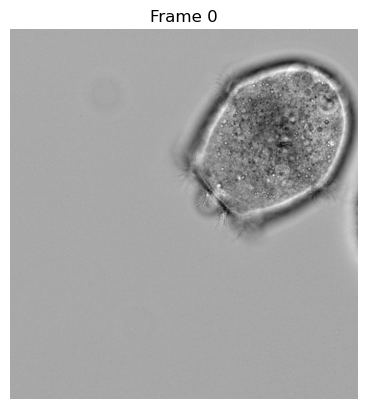

In [3]:
### Sets file path and makes output folder
file_path = file_directory + "\\" + file_name
output_path = file_directory + "output_MW_" + band_id + "\\"

if not os.path.exists(output_path):
    os.makedirs(output_path)

### Reading file info and visual inspection
image, frame_width, frame_height, num_frames   =  open_tif(file_path)

frame_index = 0
show_frame_no_axes(image,frame_index)

### Blur for registration

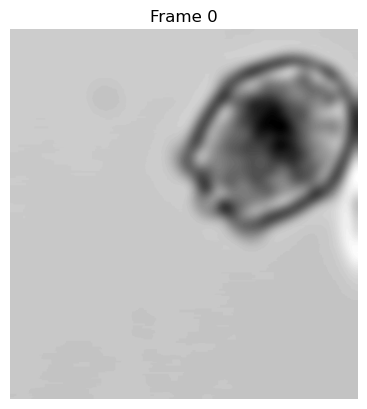

In [ ]:
### Apply Gaussian blur to the stack
blurred_stack = np.empty_like(image)
sigma_gaussian = 10

for i in range(image.shape[0]):
    blurred_stack[i] = gaussian_filter(image[i], sigma=sigma_gaussian)

show_frame_no_axes(blurred_stack,frame_index)

### Pystackreg registration

In [6]:
### Registration to obtain the transformation matrix
sr = StackReg(StackReg.RIGID_BODY)
tmat_1 = sr.register_stack(blurred_stack, axis=0)    # transformation matrix
reg_1 = sr.transform_stack(blurred_stack)

tifffile.imwrite(output_path +"pystackreg_rigid_body.tif", reg_1)
np.save(output_path +'tmat_rigid_body.npy', tmat_1)

After the first registration, confirm quality in ImageJ. If necessary a second registration is applied, after cropping the black margins. The cropped file should be saved in the output folder with the name: "pystackreg_rigid_body_spatial_crop.tif"

In [8]:
# ### 2nd registration if necessary 
# reg_cropped = tifffile.imread(output_path +  "pystackreg_rigid_body_spatial_crop.tif")

# sr = StackReg(StackReg.RIGID_BODY)
# tmat_2 = sr.register_stack(reg_cropped, axis=0)    # transformation matrix
# reg_2 = sr.transform_stack(reg_cropped)

# tifffile.imwrite(output_path +"pystackreg_rigid_body_loop2.tif", reg_2)
# np.save(output_path +'tmat_rigid_body_loop2.npy', tmat_2)

Using the obtained registration matrices, the original timelapse is then registered

In [ ]:
transformed_stack = np.empty_like(image)

for i in range(image.shape[0]):
    transformed_stack[i] = sr.transform(image[i], tmat_1[i])
tifffile.imwrite(output_path +"image_registered_1.tif", transformed_stack)

The registered timelapse is then opened in ImageJ and can be cropped around the cell to save computational time and it should be saved in the output path. If a second registration was carried out, it is also implemented on the cropped timelapse below. 

In [ ]:
transformed_stack_crop = tifffile.imread(output_path +  "image_registered_1_spatial_crop.tif")

transformed_stack_2 = np.empty_like(transformed_stack_crop)

for i in range(transformed_stack_crop.shape[0]):
    transformed_stack_2[i] = sr.transform(transformed_stack_crop[i], tmat_2[i])
tifffile.imwrite(output_path +"image_registered_2.tif", transformed_stack_2)


In [ ]:
%matplotlib qt

image_preview = transformed_stack_2[0,:,:]
output_linear_segment_file = output_path + "selected_points.csv"

select_points_line_and_save(image_preview, output_linear_segment_file)

Points and drawing saved to C:\Users\kourkoul\SCRIPTS\Paper_scripts\example_data\output_MW_anterior\selected_points.csv


### Kymograph preparation

In [4]:
### Preprocessing can be skipped by loading the files previously obtained: 
transformed_stack_2 = tifffile.imread(output_path +"image_registered_2.tif")
output_linear_segment_file = output_path + "selected_points.csv"

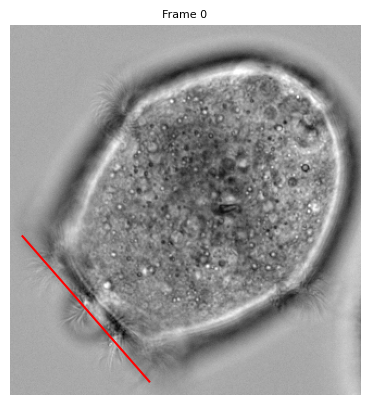

In [5]:
%matplotlib inline

### Visualize the selection of the linear segment along which the kymograph will be calculated
line_borders = read_line_borders_to_array(output_linear_segment_file)
x1, y1 = line_borders[0]
x2, y2 = line_borders[1]

plt.figure()
plt.imshow(transformed_stack_2[0], cmap = 'gray')
plt.plot([x1, x2], [y1, y2], c= 'r')
plt.title("Frame " + str(frame_index), fontsize = 8)
plt.axis(False)
plt.show()

### Get the pixel coordinates along the line
line_points = bresenham(x1, y1, x2, y2)


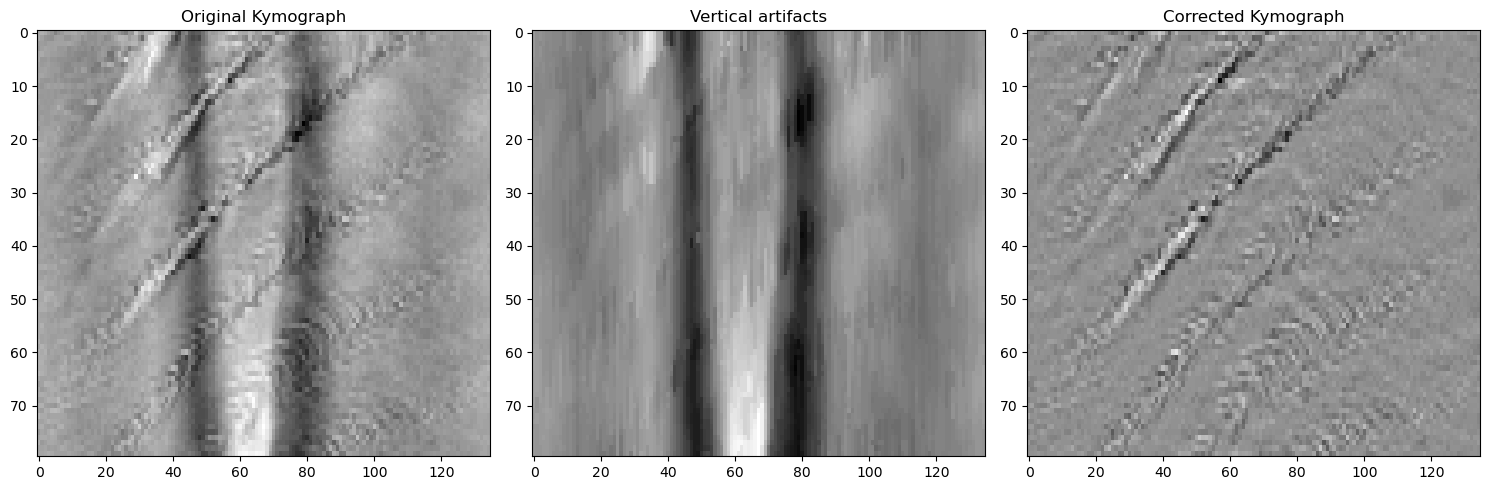

c:\Users\kourkoul\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
c:\Users\kourkoul\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:84: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduction(axis=axis, out=out, **passkwargs)


In [20]:
### Get the 1D representation of the ciliary band
x_new = np.zeros((num_frames,len(line_points)))

for i in range(num_frames):
    for j in range(len(line_points)):
        x_new[i,j] = transformed_stack_2[i,line_points[j][1],line_points[j][0]]

### If the line extends beyond the band, the excess regions can be cropped to reduce artifacts in the 2D autocorrelation: 
x_new = x_new[x_new_cut_start:x_new_cut_end,:]        

num_pixels = x_new.shape[1]   
num_frames = x_new.shape[0]   

#  Convert 'x_new' to a dataframe with the column intensity in time : 'c_intensity'
c_intensity = pd.DataFrame(index = pd.Index(np.arange(num_frames)), columns = pd.Index(range(num_pixels)))
c_intensity.index.name = 'Time (frames)'
c_intensity.columns.name = 'Position along the cilia (pixel)'

for i in range(num_pixels):
    c_intensity[i] = x_new[:,i]
    
    
### Correct for vertical artifacts from the mouth and cell body
kymograph = c_intensity
filter_size = 10
corrected_kymograph = vertical_artifacts_correction(kymograph, filter_size, output_path)


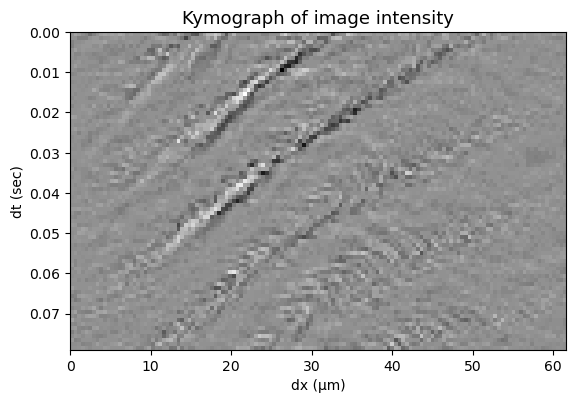

In [11]:
### Rescale to μm and sec
num_frames = corrected_kymograph.index.max() + 1
num_pixels = corrected_kymograph.columns.max() + 1

new_index = pd.Index(np.arange(num_frames) / fps)
new_columns = pd.Index(np.arange(num_pixels) * pixel_size)
    
### Adjust the indices of the dataframe
rescaled_c_intensity = corrected_kymograph.copy()
rescaled_c_intensity.index = new_index
rescaled_c_intensity.columns = new_columns
rescaled_c_intensity.index.name = 'time (sec)'
rescaled_c_intensity.columns.name = 'position along the cilia (\u03BCm)'
    
kymograph_display_units(rescaled_c_intensity)
rescaled_c_intensity.to_pickle(output_path + "rescaled_c_intensity.pkl")
plt.savefig(output_path + "rescaled_corrected_kymograph.png")# Save c_intensity:


### 2D autocorrelation

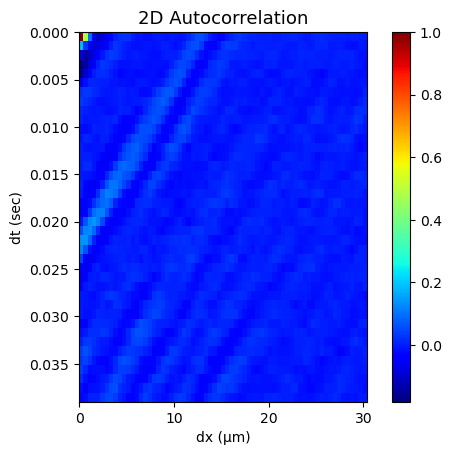

In [12]:
c = autocorrelation2D_fft_units(corrected_kymograph)
index_t = np.arange(c.shape[0])
index_x = np.arange(c.shape[1])
# Turning c to dataframe:
correlation = pd.DataFrame(data = c, index = pd.Index(index_t/fps), columns = pd.Index(index_x*pixel_size)) 
correlation.index.name = 'dt (sec)'
correlation.columns.name = 'dx (\u03BCm)'

# visualization
autocorrelation2D_visualization_units(correlation)
plt.savefig(output_path + "autocorrelation_corrected.png", dpi=300)

# Save correlation:
correlation.to_pickle(output_path + "correlation_corrected.pkl")

detected peak indices [22]
time between nodes:  0.022
frequency (Hz):  45.45454545454546
detected peak indices [11 27 37]
[27 37]
space between nodes:  12.42
wavelength 1 (μm):  12.42
space between nodes:  17.02
wavelength 2 (μm):  17.02
wavelength average (μm):  14.719999999999999
velocity perceived (μm/sec):  564.5454545454546
velocity perceived (μm/sec):  773.6363636363636


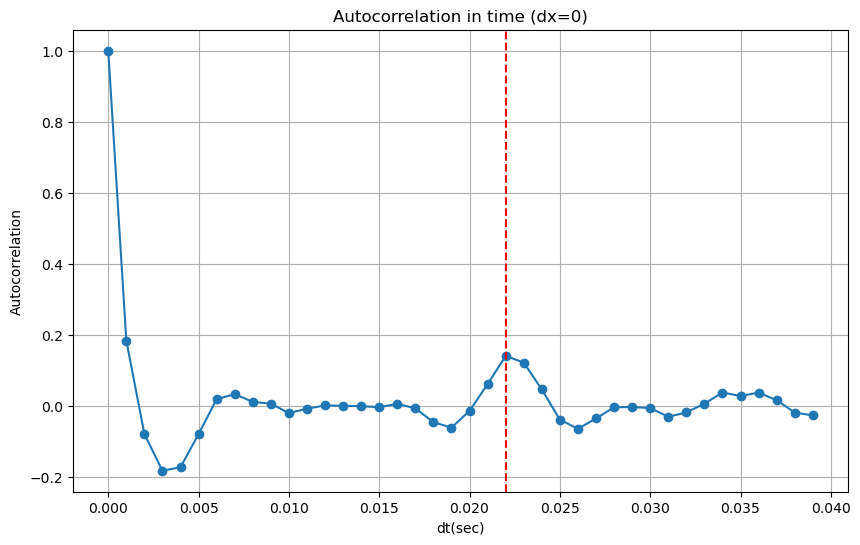

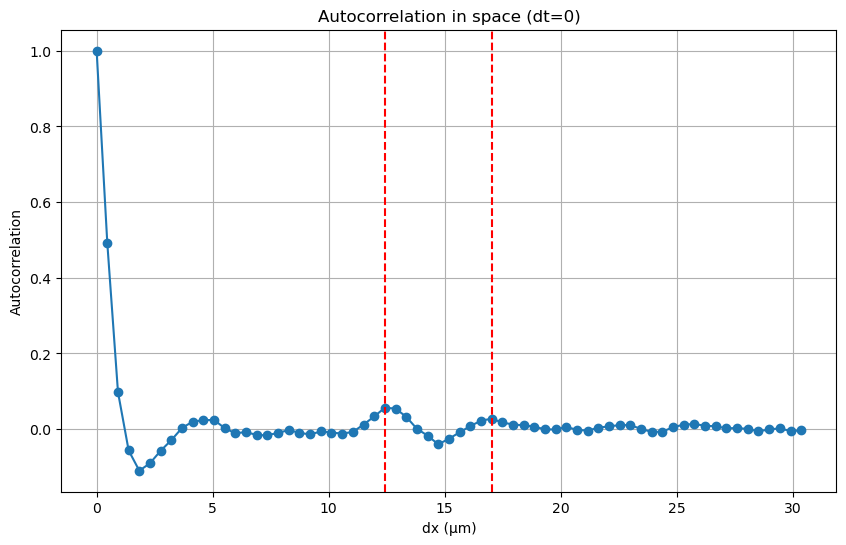

In [ ]:
# Find the peaks in autocorrelation in time:
peaks_f, _ = signal.find_peaks(correlation[0], prominence =0.1)
dt_peak, = correlation.index[peaks_f]

frequency_MW = 1/dt_peak
print("frequency (Hz): ", frequency_MW)

# Find the peaks in autocorrelation in space:
peaks_w, _ = signal.find_peaks( correlation.iloc[0, :], prominence =0.02)
ds_peak_1, = correlation.columns[[peaks_w[1]]]

wavelength_MW_1 = ds_peak_1
print("wavelength 1 (\u03BCm): ", wavelength_MW_1)

ds_peak_2, = correlation.columns[[peaks_w[2]]]
wavelength_MW_2 = ds_peak_2
print("wavelength 2 (\u03BCm): ", wavelength_MW_2)

# Velocity estimation:
velocity_perceived_1 = ds_peak_1 / dt_peak
print("velocity perceived (\u03BCm/sec): ", velocity_perceived_1)

# Quick velocity estimation:
velocity_perceived_2 = ds_peak_2 / dt_peak
print("velocity perceived (\u03BCm/sec): ", velocity_perceived_2)

plt.figure(figsize=(10, 6))
plt.plot(correlation.index, correlation[0], marker='o', linestyle='-')
plt.axvline(x=dt_peak, ymin=0, ymax=1, color='red', linestyle='--')
plt.xlabel('dt(sec)')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation in time (dx=0)')
plt.grid(True)
plt.savefig(output_path + "autocorrelation_in_time.png")

plt.figure(figsize=(10, 6))
plt.plot(correlation.columns, correlation.iloc[0, :], marker='o', linestyle='-')
plt.axvline(x=ds_peak_1, ymin=0, ymax=1, color='red', linestyle='--')
plt.axvline(x=ds_peak_2, ymin=0, ymax=1, color='red', linestyle='--')
plt.xlabel('dx (\u03BCm)')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation in space (dt=0)')
plt.grid(True)
plt.savefig(output_path + "autocorrelation_in_space.png")


### Save results

In [15]:
## Save parameters to csv:
headers_param = ['file_name','pixel_size', 'fps', 'x_new_cut_start', 'x_new_cut_end', 'dt_peak', 'frequency_MW','wavelength_MW_1', 'wavelength_MW_2', 'velocity_perceived_1', 'velocity_perceived_2']
data_parameters = [file_name, pixel_size, fps, x_new_cut_start, x_new_cut_end, dt_peak, frequency_MW, wavelength_MW_1, wavelength_MW_2, velocity_perceived_1, velocity_perceived_2]
save_csv_file(output_path+'output_results.csv', headers_param, data_parameters)

### Alternative: autocorrelation in kymograph subsection

In [18]:
# t_0 =  input_parameters["t_0"][0] 
# t_1 =  input_parameters["t_1"][0] 
# x_0 =  input_parameters["x_0"][0] 
# x_1 =  input_parameters["x_1"][0] 

# subsection = rescaled_c_intensity.iloc[t_0:t_1, x_0:x_1]


# kymograph_display_units(subsection)

In [ ]:
# # Save c_intensity:
# subsection.to_pickle(output_path + "subsection_kymograph.pkl")

# c = autocorrelation2D_fft_units(subsection)
# index_t = np.arange(c.shape[0])
# index_x = np.arange(c.shape[1])
# # Turning c to dataframe:
# correlation_subsection = pd.DataFrame(data = c, index = pd.Index(index_t/fps), columns = pd.Index(index_x*pixel_size)) 
# correlation_subsection.index.name = 'dt (sec)'
# correlation_subsection.columns.name = 'dx (\u03BCm)'

# # visualization
# autocorrelation2D_visualization_units(correlation_subsection)
# plt.savefig(output_path + "autocorrelation_corrected_subsection.png", dpi=300)

# # Save correlation:
# correlation_subsection.to_pickle(output_path + "correlation_subsection.pkl")

In [19]:
# # # Find the peaks in autocorrelation in time:
# peaks_f, _ = signal.find_peaks(correlation_subsection[0], prominence =0.05 )
# dt_peak, = correlation_subsection.index[peaks_f]

# frequency_MW = 1/dt_peak
# print("frequency (Hz): ", frequency_MW)


# # Find the peaks in autocorrelation in space:
# peaks_w, _ = signal.find_peaks( correlation_subsection.iloc[0, :], prominence =0.05 )
# ds_peak, = correlation_subsection.columns[peaks_w]

# wavelength_MW = ds_peak
# print("wavelength (\u03BCm): ", wavelength_MW)


# plt.figure(figsize=(10, 6))
# plt.plot(correlation_subsection.index, correlation_subsection[0], marker='o', linestyle='-')
# plt.axvline(x=dt_peak, ymin=0, ymax=1, color='red', linestyle='--')
# plt.xlabel('dt(sec)')
# plt.ylabel('Autocorrelation')
# plt.title('Autocorrelation in time (dx=0)')
# plt.grid(True)
# plt.savefig(output_path + "autocorrelation_in_time.png")

# plt.figure(figsize=(10, 6))
# plt.plot(correlation_subsection.columns, correlation_subsection.iloc[0, :], marker='o', linestyle='-')
# plt.axvline(x=ds_peak, ymin=0, ymax=1, color='red', linestyle='--')
# plt.xlabel('dx (\u03BCm)')
# plt.ylabel('Autocorrelation')
# plt.title('Autocorrelation in space (dt=0)')
# plt.grid(True)
# plt.savefig(output_path + "autocorrelation_in_space.png")
